<a href="https://colab.research.google.com/github/Siddharth5723/Daily_learning/blob/main/Hyperparameter_tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Tuning with GridSearchCV

This notebook demonstrates how to perform hyperparameter tuning using `GridSearchCV` from the scikit-learn library. We will use a synthetic dataset for illustration purposes.

### 1. Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Generate Synthetic Data

We'll create a simple binary classification dataset for demonstration.

In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (700, 20)
Shape of y_train: (700,)
Shape of X_test: (300, 20)
Shape of y_test: (300,)


### 3. Define the Model and Hyperparameter Grid

We'll use a Support Vector Machine (SVC) as an example model and define a grid of hyperparameters to search through. We'll also show an example for RandomForestClassifier.

In [3]:
# For Support Vector Classifier (SVC)
svc = SVC(random_state=42)
svc_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# For Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

### 4. Initialize and Run GridSearchCV

`GridSearchCV` will systematically work through multiple combinations of parameter tunes, cross-validating as it goes to determine which tune gives the best performance.

In [4]:
print("Running GridSearchCV for SVC...")
grid_search_svc = GridSearchCV(estimator=svc, param_grid=svc_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svc.fit(X_train, y_train)
print("SVC GridSearchCV complete.")

print("\nRunning GridSearchCV for RandomForestClassifier...")
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)
print("RandomForestClassifier GridSearchCV complete.")

Running GridSearchCV for SVC...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
SVC GridSearchCV complete.

Running GridSearchCV for RandomForestClassifier...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
RandomForestClassifier GridSearchCV complete.


### 5. Display Best Parameters and Score

After fitting, we can inspect the best parameters found and the corresponding best score.

In [5]:
print("--- SVC Results ---")
print(f"Best parameters for SVC: {grid_search_svc.best_params_}")
print(f"Best cross-validation accuracy for SVC: {grid_search_svc.best_score_:.4f}")

print("\n--- RandomForestClassifier Results ---")
print(f"Best parameters for RandomForestClassifier: {grid_search_rf.best_params_}")
print(f"Best cross-validation accuracy for RandomForestClassifier: {grid_search_rf.best_score_:.4f}")

--- SVC Results ---
Best parameters for SVC: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy for SVC: 0.9443

--- RandomForestClassifier Results ---
Best parameters for RandomForestClassifier: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy for RandomForestClassifier: 0.9300


### 6. Evaluate Best Model on Test Set

Use the best estimator found by `GridSearchCV` to make predictions on the unseen test data and evaluate its performance.

In [6]:
best_svc_model = grid_search_svc.best_estimator_
y_pred_svc = best_svc_model.predict(X_test)
svc_test_accuracy = accuracy_score(y_test, y_pred_svc)
print(f"Test accuracy with best SVC model: {svc_test_accuracy:.4f}")

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Test accuracy with best RandomForestClassifier model: {rf_test_accuracy:.4f}")

Test accuracy with best SVC model: 0.9500
Test accuracy with best RandomForestClassifier model: 0.9167


### 7. Visualize GridSearchCV Results (Optional)

We can also visualize the results of the grid search to better understand how different hyperparameters affect performance.

,param_C,param_kernel,param_gamma,mean_test_score,rank_test_score
5,1.0,rbf,scale,0.944267,1
7,1.0,rbf,auto,0.941418,2
15,100.0,rbf,auto,0.939988,3
11,10.0,rbf,auto,0.939988,3
9,10.0,rbf,scale,0.939981,5


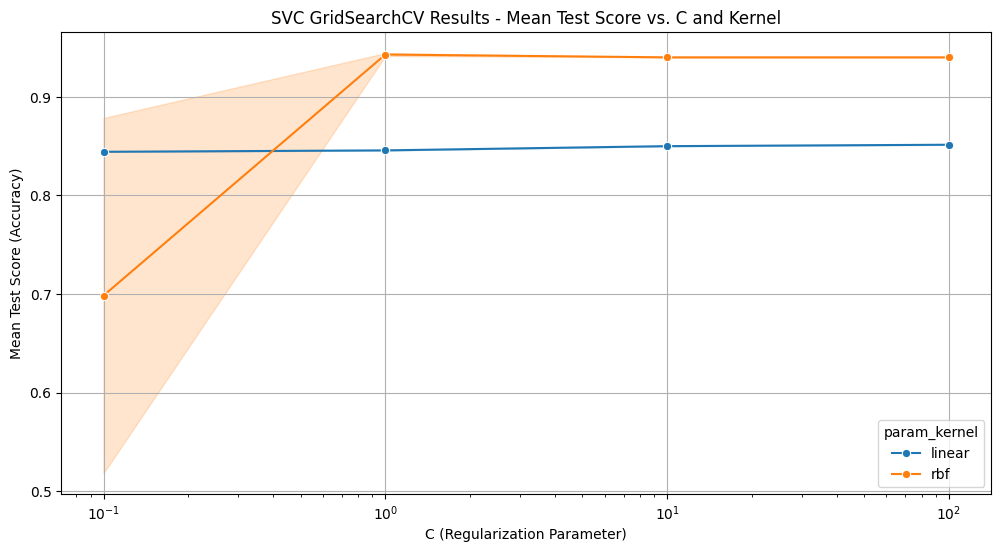

In [7]:
results_svc = pd.DataFrame(grid_search_svc.cv_results_)
display(results_svc[['param_C', 'param_kernel', 'param_gamma', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head())

plt.figure(figsize=(12, 6))
sns.lineplot(data=results_svc, x='param_C', y='mean_test_score', hue='param_kernel', marker='o')
plt.xscale('log')
plt.title('SVC GridSearchCV Results - Mean Test Score vs. C and Kernel')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Mean Test Score (Accuracy)')
plt.grid(True)
plt.show()

### Conclusion

This notebook provided a comprehensive example of using `GridSearchCV` for hyperparameter tuning. It's a powerful tool for finding the optimal combination of hyperparameters for your machine learning models.